In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from PIL import Image

In [ ]:
import wandb
wandb.login(key="your-key-here")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/lucapopescu/.netrc
wandb: Currently logged in as: luca-popescu (luca-popescu-san-jose-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
device = torch.device("mps")
print(f"Using device: {device}")

Using device: mps


In [4]:
ds = load_dataset("tridentio/ships-combined", streaming=True)

train_ds = ds["train"]
val_ds   = ds["val"]
test_ds  = ds["test"]

print("Dataset splits loaded:")
print(f"  Train: {train_ds}")
print(f"  Val:   {val_ds}")
print(f"  Test:  {test_ds}")

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Dataset splits loaded:
  Train: IterableDataset({
    features: ['image', 'label', 'source'],
    num_shards: 41
})
  Val:   IterableDataset({
    features: ['image', 'label', 'source'],
    num_shards: 9
})
  Test:  IterableDataset({
    features: ['image', 'label', 'source'],
    num_shards: 9
})


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [6]:
def preprocess(transform):
    def process(example):
        image = example["image"].convert("RGB")
        example["pixel_values"] = transform(image)
        return example
    return process

train_ds = (
    train_ds
    .shuffle(seed=42, buffer_size=2000)
    .map(preprocess(train_transform))
    .select_columns(["pixel_values", "label"])
)

val_ds = (
    val_ds
    .map(preprocess(eval_transform))
    .select_columns(["pixel_values", "label"])
)

test_ds = (
    test_ds
    .map(preprocess(eval_transform))
    .select_columns(["pixel_values", "label"])
)

print("Transforms mapped to splits successfully")
print(f"Train features: {train_ds.features}")

Transforms mapped to splits successfully
Train features: None


In [7]:
def collate_fn(batch):
    images = torch.stack([b["pixel_values"] for b in batch])
    labels = torch.tensor([b["label"] for b in batch], dtype=torch.float32).unsqueeze(1)
    return images, labels

train_loader = DataLoader(train_ds, batch_size=16, collate_fn=collate_fn,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=16, collate_fn=collate_fn,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=16, collate_fn=collate_fn,
                          num_workers=0, pin_memory=False)

print("DataLoaders ready")

DataLoaders ready


In [ ]:
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load("/your/path/here",
                                  map_location=device))
model = model.to(device)

print(f"Model loaded and on: {next(model.parameters()).device}")

Model loaded and on: mps:0


In [9]:
pos_weight = torch.tensor([3.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                        factor=0.1, patience=3)
print("Loss, optimizer and scheduler ready")

Loss, optimizer and scheduler ready


In [10]:
batch = next(iter(train_loader))
images, labels = batch
print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16, 1])


In [ ]:
import time

NUM_EPOCHS = 1
TRAIN_STEPS = 138000 // 16
VAL_STEPS   = 29500  // 16

# Initialize WandB run
wandb.init(
    project="ship-detection",
    config={
        "epochs": NUM_EPOCHS,
        "batch_size": 16,
        "learning_rate": 1e-4,
        "image_size": 224,
        "pos_weight": 3.0,
        "model": "resnet18",
        "dataset": "tridentio/ships-combined",
    }
)

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    epoch_start = time.time()
    batch_start = time.time()

    for i, (images, labels) in enumerate(train_loader):
        load_time = time.time() - batch_start

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_time = time.time() - batch_start

        # Log every 100 steps
        if (i + 1) % 100 == 0:
            avg_loss = running_loss / (i + 1)
            elapsed = time.time() - epoch_start
            steps_remaining = TRAIN_STEPS - (i + 1)
            time_per_step = elapsed / (i + 1)
            eta_minutes = (steps_remaining * time_per_step) / 60

            print(f"  Epoch {epoch+1} | Step {i+1}/{TRAIN_STEPS} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Batch load: {load_time*1000:.1f}ms | "
                  f"Step time: {train_time*1000:.1f}ms | "
                  f"Elapsed: {elapsed/60:.1f}min | "
                  f"ETA: {eta_minutes:.1f}min")

            # Log step metrics to WandB
            wandb.log({
                "train_loss_step": avg_loss,
                "batch_load_ms": load_time * 1000,
                "step_time_ms": train_time * 1000,
                "step": i + 1,
            })

        batch_start = time.time()

    train_loss = running_loss / TRAIN_STEPS
    train_losses.append(train_loss)
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1} training done in {epoch_time/60:.1f}min | "
          f"Train Loss: {train_loss:.4f}")

    # --- Validation phase ---
    print(f"Running validation...")
    model.eval()
    val_loss = 0.0
    val_start = time.time()

    with torch.no_grad():
        for j, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            if (j + 1) % 100 == 0:
                print(f"  Val step {j+1}/{VAL_STEPS} | "
                      f"Elapsed: {(time.time()-val_start)/60:.1f}min")

    val_loss = val_loss / VAL_STEPS
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Log epoch metrics to WandB
    wandb.log({
        "train_loss_epoch": train_loss,
        "val_loss_epoch": val_loss,
        "epoch": epoch + 1,
        "epoch_time_min": epoch_time / 60,
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/your/path/here")
        print(f"  ✓ New best model saved")

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val time: {(time.time()-val_start)/60:.1f}min\n")

# Close the WandB run
wandb.finish()
print("Training complete!")

  Epoch 1 | Step 100/8625 | Loss: 0.7713 | Batch load: 46.1ms | Step time: 120.2ms | Elapsed: 0.4min | ETA: 35.0min
  Epoch 1 | Step 200/8625 | Loss: 0.6164 | Batch load: 49.2ms | Step time: 123.6ms | Elapsed: 0.6min | ETA: 26.1min
  Epoch 1 | Step 300/8625 | Loss: 0.5327 | Batch load: 76.6ms | Step time: 153.3ms | Elapsed: 0.9min | ETA: 24.5min
  Epoch 1 | Step 400/8625 | Loss: 0.4868 | Batch load: 48.4ms | Step time: 122.6ms | Elapsed: 1.1min | ETA: 22.6min
  Epoch 1 | Step 500/8625 | Loss: 0.4601 | Batch load: 52.7ms | Step time: 129.7ms | Elapsed: 1.3min | ETA: 21.3min
  Epoch 1 | Step 600/8625 | Loss: 0.4364 | Batch load: 52.5ms | Step time: 129.5ms | Elapsed: 1.6min | ETA: 21.3min
  Epoch 1 | Step 700/8625 | Loss: 0.4163 | Batch load: 49.7ms | Step time: 132.8ms | Elapsed: 1.8min | ETA: 20.6min
  Epoch 1 | Step 800/8625 | Loss: 0.3982 | Batch load: 48.9ms | Step time: 123.0ms | Elapsed: 2.6min | ETA: 25.8min
  Epoch 1 | Step 900/8625 | Loss: 0.3910 | Batch load: 54.7ms | Step tim

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/tridentio/ships-combined/resolve/9ce240e462370d7f7099a3268f79432539b0076d/data/train-00035-of-00041.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/tridentio/ships-combined/resolve/9ce240e462370d7f7099a3268f79432539b0076d/data/train-00035-of-00041.parquet
Retrying in 1s [Retry 1/5].


  Epoch 1 | Step 2500/8625 | Loss: 0.3109 | Batch load: 45.5ms | Step time: 118.3ms | Elapsed: 25.2min | ETA: 61.7min
  Epoch 1 | Step 2600/8625 | Loss: 0.3081 | Batch load: 47.7ms | Step time: 120.1ms | Elapsed: 26.0min | ETA: 60.2min


'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/tridentio/ships-combined/resolve/9ce240e462370d7f7099a3268f79432539b0076d/data/train-00024-of-00041.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/tridentio/ships-combined/resolve/9ce240e462370d7f7099a3268f79432539b0076d/data/train-00024-of-00041.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/tridentio/ships-combined/resolve/9ce240e462370d7f7099a3268f79432539b0076d/data/train-00024-of-00041.parquet
Retrying in 1s [Retry 1/5].


  Epoch 1 | Step 2700/8625 | Loss: 0.3052 | Batch load: 46.9ms | Step time: 118.8ms | Elapsed: 36.5min | ETA: 80.1min


...

  Val step 500/1843 | Elapsed: 29.1min
  Val step 600/1843 | Elapsed: 29.6min
  Val step 700/1843 | Elapsed: 32.2min
  Val step 800/1843 | Elapsed: 32.7min
  Val step 900/1843 | Elapsed: 34.9min
  Val step 1000/1843 | Elapsed: 35.9min


Got disconnected from remote data host. Retrying in 5sec [1/20]


  Val step 1100/1843 | Elapsed: 38.6min
  Val step 1200/1843 | Elapsed: 39.8min
  Val step 1300/1843 | Elapsed: 42.1min
  Val step 1400/1843 | Elapsed: 43.2min
  Val step 1500/1843 | Elapsed: 45.5min
  Val step 1600/1843 | Elapsed: 46.6min
  Val step 1700/1843 | Elapsed: 48.8min
  Val step 1800/1843 | Elapsed: 49.9min
  ✓ New best model saved
Epoch 1/1 | Train Loss: 0.2354 | Val Loss: 0.1682 | Val time: 49.9min



batch_load_ms,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▅▁▁▁▁▁▁▁▁▁
epoch,▁
epoch_time_min,▁
step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇████
step_time_ms,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_epoch,▁
train_loss_step,█▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_epoch,▁
batch_load_ms,20.66994
epoch,1
epoch_time_min,149.1584


Training complete!


In [11]:
from datasets import load_dataset

# Re-initialize the test stream
ds = load_dataset("tridentio/ships-combined", streaming=True)

test_ds = (
    ds["test"]
    .map(preprocess(eval_transform))
    .select_columns(["pixel_values", "label"])
)

test_loader = DataLoader(test_ds, batch_size=16, collate_fn=collate_fn,
                         num_workers=0, pin_memory=False)

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Running evaluation on test set...
              precision    recall  f1-score   support

     No Ship       0.99      0.95      0.97     22950
        Ship       0.84      0.97      0.90      6534

    accuracy                           0.95     29484
   macro avg       0.92      0.96      0.93     29484
weighted avg       0.96      0.95      0.95     29484



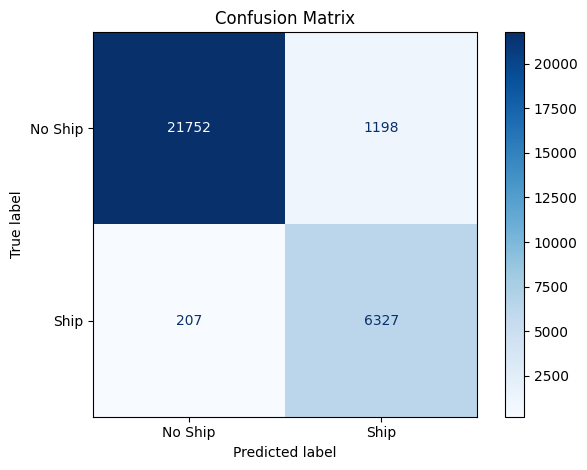

Confusion matrix logged to WandB


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageFile

# Allow PIL to load truncated images instead of crashing
ImageFile.LOAD_TRUNCATED_IMAGES = True

model.load_state_dict(torch.load("/your/path/here",
                                  map_location=device))
model.eval()

all_preds = []
all_labels = []

print("Running evaluation on test set...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= 0.5).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.squeeze(1).cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print(classification_report(all_labels, all_preds, target_names=['No Ship', 'Ship']))

# Display confusion matrix in notebook
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Ship', 'Ship'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Log confusion matrix to WandB
wandb.init(project="ship-detection", name="evaluation", resume="allow")
wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(
    probs=None,
    y_true=all_labels.tolist(),
    preds=all_preds.tolist(),
    class_names=['No Ship', 'Ship']
)})
wandb.finish()
print("Confusion matrix logged to WandB")